# 10 – Proveedor de Propiedades para CFD y Cinética Química

Los solvers de Dinámica de Fluidos Computacional (CFD) y de cinética química
necesitan evaluar propiedades termoquímicas **millones de veces** — una vez por
celda por paso de tiempo. Llamar a la API completa de `pyglenn` (consulta SQL +
evaluación polinomial) en cada iteración es un desperdicio; un enfoque mejor es
**precargar** los coeficientes en memoria y usar bucles de evaluación
especialmente optimizados.

Este cuaderno muestra:

1. **Tablas de propiedades por lotes** — DataFrames de pandas con $C_p(T)$,
   $H(T)$, $S(T)$ en una malla de temperaturas para cualquier conjunto de
   especies
2. **Proveedor de coeficientes en caché** — precarga de coeficientes NASA en
   arrays NumPy para evaluación vectorizada en memoria
3. **Benchmark** — proveedor en caché vs. llamada bruta a la API
4. **Integración de EDOs** — acoplando `pyglenn` con `scipy.integrate.solve_ivp`
   para el balance de energía de un PFR (reactor de flujo pistón) no isotérmico

Todas las mediciones de tiempo son ilustrativas; los valores absolutos dependen
de la máquina.

In [1]:
from pyglenn import ThermochemicalCalculator, R

_INDEX = {}

def species_id(calc, name):
    """Devuelve el id en la base de datos de la especie cuyo *nombre* coincide exactamente."""
    if not _INDEX:
        _INDEX.update({s["name"]: s["id"] for s in calc.get_available_species("")})
    if name not in _INDEX:
        raise ValueError(f"Especie {name!r} no encontrada en la base de datos")
    return _INDEX[name]

print("Constante universal de los gases R =", R, "J/(mol.K)")


Constante universal de los gases R = 8.314462618 J/(mol.K)


In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

import time
from scipy.integrate import solve_ivp

## 1. Tablas de propiedades por lotes

Generar una tabla de $C_p(T)$ para varias especies en una malla de temperaturas
compartida es sencillo. Esta es la estrategia "offline" más simple: precalcule
una vez, consulte rápidamente durante la simulación.

In [3]:
def batch_properties(calc, species_names, T_grid):
    """Devuelve DataFrame con Cp [J/mol·K], H [kJ/mol], S [J/mol·K].

    Filas = temperaturas, columnas = MultiIndex (propiedad, especie).
    """
    ids = {name: species_id(calc, name) for name in species_names}
    records = []
    for T in T_grid:
        row = {"T": T}
        for name, sid in ids.items():
            p = calc.calculate_properties(sid, T)
            row[(name, "Cp")] = p["cp"]
            row[(name, "H")]  = p["h_relative"] / 1000
            row[(name, "S")]  = p["s"]
        records.append(row)

    df = pd.DataFrame(records).set_index("T")
    df.columns = pd.MultiIndex.from_tuples(df.columns, names=["especie", "propiedad"])
    return df

species_list = ["CH4", "O2", "N2", "CO2", "H2O", "CO", "H2"]
T_grid = np.linspace(300, 3000, 28)

with ThermochemicalCalculator() as calc:
    tbl = batch_properties(calc, species_list, T_grid)

print("Dimensión:", tbl.shape)
print()
print("Cp [J/(mol·K)] a temperaturas seleccionadas:")
print(tbl.xs("Cp", axis=1, level="propiedad").round(1).head(8))


Dimensión: (28, 21)

Cp [J/(mol·K)] a temperaturas seleccionadas:
especie      CH4     O2     N2    CO2    H2O     CO     H2
T                                                         
300.000   35.800 29.400 29.100 37.200 33.600 29.100 28.800
400.000   40.600 30.100 29.200 41.300 34.300 29.300 29.200
500.000   46.600 31.100 29.600 44.600 35.200 29.800 29.300
600.000   52.700 32.100 30.100 47.300 36.300 30.400 29.300
700.000   58.500 33.000 30.800 49.600 37.500 31.200 29.400
800.000   64.000 33.700 31.400 51.400 38.700 31.900 29.600
900.000   69.100 34.400 32.100 53.000 40.000 32.600 29.900
1,000.000 73.700 34.900 32.700 54.300 41.300 33.200 30.200


## 2. Proveedor de coeficientes en caché

Para uso en producción con CFD/cinética, queremos evaluar $C_p(T)$, $H(T)$,
$S(T)$ **sin consultas SQL**. La estrategia:

1. Consultar la base de datos **una vez** para extraer los coeficientes de cada
   especie para cada intervalo de temperatura.
2. Almacenarlos en arrays NumPy (`coeffs[N_especies, N_intervalos, 9]`) y un
   array complementario `intervals[N_especies, N_intervalos, 2]`.
3. En tiempo de ejecución, buscar binariamente el intervalo y evaluar el
   polinomio directamente.

Esto reduce una llamada de ~50 µs (SQL + Python) a una evaluación de ~1 µs en
NumPy puro.

In [4]:
class CachedPropertyProvider:
    """Precarga coeficientes NASA para un conjunto de especies en arrays NumPy.

    Una vez construido, ``cp(idx_esp, T)`` / ``h(idx_esp, T)`` / ``s(idx_esp, T)``
    evalúan en microsegundos sin acceso a la base de datos.
    """

    def __init__(self, calc, species_names):
        self.names = list(species_names)
        self.name_to_idx = {n: i for i, n in enumerate(self.names)}
        n_spec = len(self.names)

        species_data = [calc.db.get_species_data(species_id(calc, name))
                        for name in self.names]
        max_intervals = max(len(sd["intervals"]) for sd in species_data)

        self.coeffs = np.full((n_spec, max_intervals, 9), np.nan)
        self.intervals = np.full((n_spec, max_intervals, 2), np.nan)
        self.n_intervals = np.zeros(n_spec, dtype=int)

        for i, sd in enumerate(species_data):
            n_int = len(sd["intervals"])
            self.n_intervals[i] = n_int
            for j, interval in enumerate(sd["intervals"]):
                c = interval["coefficients"]
                self.coeffs[i, j, :] = [c["a1"], c["a2"], c["a3"], c["a4"],
                                         c["a5"], c["a6"], c["a7"],
                                         c["b1"], c["b2"]]
                self.intervals[i, j, :] = [interval["temp_min"],
                                            interval["temp_max"]]

    def _find_interval(self, i, T):
        for j in range(self.n_intervals[i]):
            if self.intervals[i, j, 0] <= T <= self.intervals[i, j, 1]:
                return j
        raise ValueError(f"T={T} fuera de rango para {self.names[i]}")

    def cp(self, i, T):
        j = self._find_interval(i, T)
        a1, a2, a3, a4, a5, a6, a7 = self.coeffs[i, j, :7]
        cp_r = (a1/T**2 + a2/T + a3 + a4*T + a5*T**2 + a6*T**3 + a7*T**4)
        return cp_r * R

    def h(self, i, T):
        j = self._find_interval(i, T)
        a1, a2, a3, a4, a5, a6, a7, b1, b2 = self.coeffs[i, j, :]
        h_rt = (-a1/T**2 + a2*np.log(T)/T + a3 + a4*T/2 + a5*T**2/3
                + a6*T**3/4 + a7*T**4/5 + b1/T)
        return h_rt * R * T

    def s(self, i, T):
        j = self._find_interval(i, T)
        a1, a2, a3, a4, a5, a6, a7, b1, b2 = self.coeffs[i, j, :]
        s_r = (-a1/(2*T**2) - a2/T + a3*np.log(T) + a4*T + a5*T**2/2
               + a6*T**3/3 + a7*T**4/4 + b2)
        return s_r * R


with ThermochemicalCalculator() as calc:
    provider = CachedPropertyProvider(calc, ["CH4", "O2", "N2", "CO2", "H2O"])

with ThermochemicalCalculator() as calc:
    for name in ["CH4", "CO2", "H2O"]:
        i = provider.name_to_idx[name]
        api = calc.calculate_properties(species_id(calc, name), 1500.0)
        print(f"{name:>4s}  Cp API={api['cp']:8.2f}  caché={provider.cp(i, 1500):8.2f}  "
              f"H API={api['h_relative']/1000:8.2f}  caché={provider.h(i, 1500)/1000:8.2f}  "
              f"S API={api['s']:8.3f}  caché={provider.s(i, 1500):8.3f}")


 CH4  Cp API=   90.87  caché=   90.87  H API=    5.59  caché=    5.59  S API= 281.749  caché= 281.749
 CO2  Cp API=   58.37  caché=   58.37  H API= -331.80  caché= -331.80  S API= 292.197  caché= 292.197
 H2O  Cp API=   47.32  caché=   47.32  H API= -193.62  caché= -193.62  S API= 250.657  caché= 250.657


## 3. Benchmark: caché vs. API bruta

Medimos el rendimiento para evaluaciones repetidas de $C_p(T)$. El proveedor en
caché debe ser **10–50× más rápido** porque evita consultas SQL, construcción de
diccionarios de resultado y marshalling a nivel Python.

In [5]:
N = 5000
T_test = np.random.uniform(400, 2500, N)
species_bench = ["CH4", "O2", "N2", "CO2", "H2O"]

with ThermochemicalCalculator() as calc:
    prov = CachedPropertyProvider(calc, species_bench)

t0 = time.perf_counter()
for k in range(N):
    _ = prov.cp(k % len(species_bench), T_test[k])
t_cached = time.perf_counter() - t0

with ThermochemicalCalculator() as calc:
    ids_bench = [species_id(calc, n) for n in species_bench]
    t0 = time.perf_counter()
    for k in range(N):
        _ = calc.calculate_properties(ids_bench[k % len(species_bench)],
                                       T_test[k])["cp"]
t_raw = time.perf_counter() - t0

print(f"{'Método':<12s} {'Tiempo':>10s} {'por llamada':>12s} {'aceleración':>10s}")
print("-" * 46)
print(f"{'Caché':<12s} {t_cached:8.4f} s {t_cached/N*1e6:8.1f} µs {t_raw/t_cached:10.1f}x")
print(f"{'API bruta':<12s} {t_raw:8.4f} s {t_raw/N*1e6:8.1f} µs {'-':>10s}")


Método           Tiempo  por llamada aceleración
----------------------------------------------
Caché          0.0113 s      2.3 µs       17.6x
API bruta      0.1978 s     39.6 µs          -


## 4. Integración de EDO: balance de energía de PFR no isotérmico

Considere un reactor de flujo pistón (PFR) donde una reacción exotérmica de
primer orden

$$\mathrm{A} \rightarrow \mathrm{B}, \quad r = k(T)\,C_A, \quad
k(T) = A \exp(-E_a/RT)$$

libera calor $\Delta H_\mathrm{rxn} < 0$. El balance de energía se acopla al
balance de masa mediante $C_p(T)$:

$$
\begin{aligned}
\frac{dC_A}{dt} &= -k(T)\,C_A \\[4pt]
\frac{dT}{dt}   &= -\frac{\Delta H_\mathrm{rxn}}{\rho\,C_p(T)}\,
                   \frac{dC_A}{dt}
\end{aligned}
$$

Usamos `pyglenn` para proporcionar el $C_p(T)$ *real* de la mezcla gaseosa
(modelada como N₂, el gas portador) vía el proveedor en caché, e integramos con
`scipy.solve_ivp`.

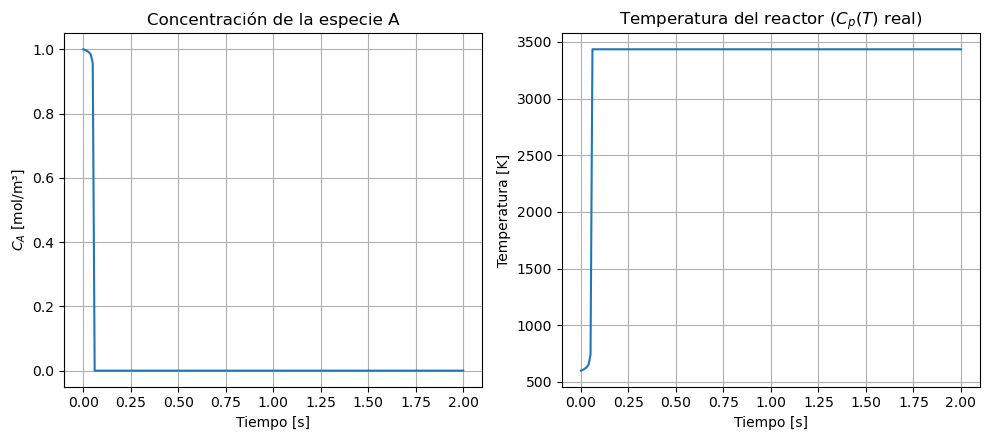

Conversión final: 100.0%
Temperatura final: 3435.4 K
Elevación de temperatura: 2835.4 K


In [6]:
A_pre = 1e8; Ea = 100e3; dH_rxn = -100e3; rho = 1.0
CA0 = 1.0; T0 = 600.0

with ThermochemicalCalculator() as calc:
    prov_ode = CachedPropertyProvider(calc, ["N2"])
i_N2 = prov_ode.name_to_idx["N2"]

def pfr_ode(t, y):
    CA, T = y
    k = A_pre * np.exp(-Ea / (R * T))
    dCA_dt = -k * CA
    cp_val = prov_ode.cp(i_N2, T)
    dT_dt = (-dH_rxn / (rho * cp_val)) * (-dCA_dt)
    return [dCA_dt, dT_dt]

t_span = (0, 2.0)
t_eval = np.linspace(0, 2, 200)
sol = solve_ivp(pfr_ode, t_span, [CA0, T0], t_eval=t_eval,
                method="RK45", rtol=1e-8, atol=1e-10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))
ax1.plot(sol.t, sol.y[0])
ax1.set_xlabel("Tiempo [s]"); ax1.set_ylabel("$C_A$ [mol/m³]")
ax1.set_title("Concentración de la especie A")
ax2.plot(sol.t, sol.y[1])
ax2.set_xlabel("Tiempo [s]"); ax2.set_ylabel("Temperatura [K]")
ax2.set_title("Temperatura del reactor ($C_p(T)$ real)")
plt.tight_layout(); plt.show()

print(f"Conversión final: {(1 - sol.y[0,-1]/CA0)*100:.1f}%")
print(f"Temperatura final: {sol.y[1,-1]:.1f} K")
print(f"Elevación de temperatura: {sol.y[1,-1] - T0:.1f} K")


## 5. Sensibilidad al modelo de capacidad calorífica

Para destacar por qué el $C_p(T)$ real importa, re-ejecutamos el PFR con una
aproximación de $C_p$ constante (usando el valor del N₂ a 600 K) y comparamos
las trayectorias de temperatura.

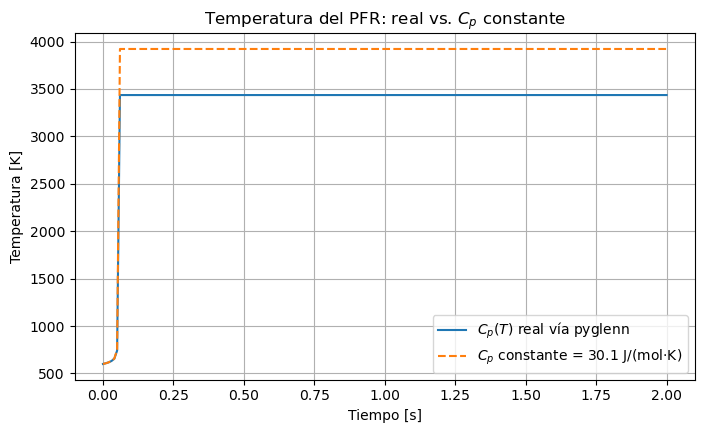

Elevación de temperatura (Cp real):  2835.4 K
Elevación de temperatura (Cp const): 3321.3 K
Diferencia relativa:                 17.1%


In [7]:
cp_const = prov_ode.cp(i_N2, 600.0)

def pfr_const_cp(t, y):
    CA, T = y
    k = A_pre * np.exp(-Ea / (R * T))
    dCA_dt = -k * CA
    dT_dt = (-dH_rxn / (rho * cp_const)) * (-dCA_dt)
    return [dCA_dt, dT_dt]

sol_const = solve_ivp(pfr_const_cp, t_span, [CA0, T0], t_eval=t_eval,
                      method="RK45", rtol=1e-8, atol=1e-10)

fig, ax = plt.subplots()
ax.plot(sol.t, sol.y[1], label="$C_p(T)$ real vía pyglenn")
ax.plot(sol_const.t, sol_const.y[1], "--", label=f"$C_p$ constante = {cp_const:.1f} J/(mol·K)")
ax.set_xlabel("Tiempo [s]"); ax.set_ylabel("Temperatura [K]")
ax.set_title("Temperatura del PFR: real vs. $C_p$ constante")
ax.legend(); plt.show()

dT_real = sol.y[1, -1] - T0
dT_const = sol_const.y[1, -1] - T0
print(f"Elevación de temperatura (Cp real):  {dT_real:.1f} K")
print(f"Elevación de temperatura (Cp const): {dT_const:.1f} K")
print(f"Diferencia relativa:                 {abs(dT_real - dT_const) / dT_real * 100:.1f}%")


## 6. Construyendo una tabla de interpolación para búsquedas CFD ultra-rápidas

Para la ruta más rápida posible — necesaria cuando $C_p$ se requiere en millones
de puntos de malla — precalcule una tabla densa en $T$ y use interpolación
lineal. Esto mide el costo adicional de la interpolación.

In [8]:
T_dense = np.linspace(300, 3000, 2000)
with ThermochemicalCalculator() as calc:
    cp_table = np.array([calc.calculate_properties(species_id(calc, "N2"), T)["cp"]
                         for T in T_dense])

N_lookup = 100000
T_rand = np.random.uniform(300, 3000, N_lookup)

t0 = time.perf_counter()
cp_interp = np.interp(T_rand, T_dense, cp_table)
t_interp = time.perf_counter() - t0

with ThermochemicalCalculator() as calc:
    prov_lookup = CachedPropertyProvider(calc, ["N2"])
iN2 = prov_lookup.name_to_idx["N2"]

t0 = time.perf_counter()
cp_cached = np.array([prov_lookup.cp(iN2, T) for T in T_rand])
t_cached = time.perf_counter() - t0

print(f"{'Método':<20s} {'Tiempo':>10s} {'por llamada':>12s} {'aceleración':>10s}")
print("-" * 52)
print(f"{'np.interp (tabla)':<20s} {t_interp:8.4f} s {t_interp/N_lookup*1e6:8.1f} µs {t_cached/t_interp:10.1f}x")
print(f"{'Proveedor caché':<20s} {t_cached:8.4f} s {t_cached/N_lookup*1e6:8.1f} µs {'-':>10s}")

print(f"\nError máximo de interpolación: {abs(cp_interp - cp_cached).max():.4f} J/(mol·K)")


Método                   Tiempo  por llamada aceleración
----------------------------------------------------
np.interp (tabla)      0.0042 s      0.0 µs       54.8x
Proveedor caché        0.2327 s      2.3 µs          -

Error máximo de interpolación: 0.0000 J/(mol·K)


## Resumen

| Estrategia | Rendimiento | Coste de setup | Memoria | Ideal para |
|---|---|---|---|---|
| API bruta de `pyglenn` | ~50 µs/llamada | Ninguno | Mínima | Trabajo interactivo |
| Proveedor de coeficientes en caché | ~1–5 µs/llamada | Barrido único BD | ~kB | Solvers EDO / cinética |
| Tabla de interpolación precalculada | ~0,1 µs/llamada | Evaluación única en malla | ~kB–MB | CFD en producción |

- El **proveedor de coeficientes en caché** elimina el costo de SQL manteniendo
  la precisión polinomial completa — ideal para integración de EDOs.
- Las **tablas de interpolación** son la opción más rápida para CFD a gran
  escala, pero introducen un error de discretización controlable.
- `pyglenn` se integra perfectamente con `scipy.integrate.solve_ivp`: basta con
  pasar una llamada a `CachedPropertyProvider.cp(T)` en la función del lado
  derecho.

Esto completa la serie de diez cuadernos. Las herramientas y patrones
presentados aquí cubren todo el espectro, desde la exploración interactiva
(cuadernos 01–04) hasta la combustión aplicada (05–07) y el equilibrio (08),
pasando por el análisis de ciclos (09) y la provisión de propiedades de alto
rendimiento (10).